# 05 - Proje Sonuç Raporu (Final Report)

Bu proje, açık üniversite (OULAD) öğrencilerinin akademik başarı durumlarını tahmin etmeyi amaçlamıştır. Veri ön işleme aşamasında **hedef veri sızıntısı (data leakage)** yaratabilecek özellikler (örn. `date_unregistration`) çıkarılmış, dengeli bir `GroupShuffleSplit` uygulanmış ve hiperparametre optimizasyonu ile makine öğrenmesi modelleri eğitilmiştir.

## 1. Model Performans Özeti
Lojistik Regresyon, Random Forest ve XGBoost modelleri değerlendirilmiştir. Veri sızıntısı giderildikten sonra modeller **%75 - %76** bandında gerçekçi bir doğruluk (accuracy) değerine ulaşmıştır. XGBoost modeli sınıflandırmada en başarılı model olmuştur.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')['target']
xgb_model = joblib.load('../models/xgb_model.pkl')

preds = xgb_model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Final XGBoost Test Doğruluğu: {acc:.4f}")

Final XGBoost Test Doğruluğu: 0.7608


## 2. Özellik Önemleri (Feature Importance)
Modelin öğrenci başarısını tahmin ederken en çok hangi özelliklere dikkat ettiğini görmek, eğitim politikalarını belirlemek için çok kritiktir. Aşağıda XGBoost modelinin özellik önem grafiği sunulmuştur.

C:\Users\Asus\AppData\Local\Temp\ipykernel_9796\1010171212.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Önem', y='Özellik', palette='viridis')


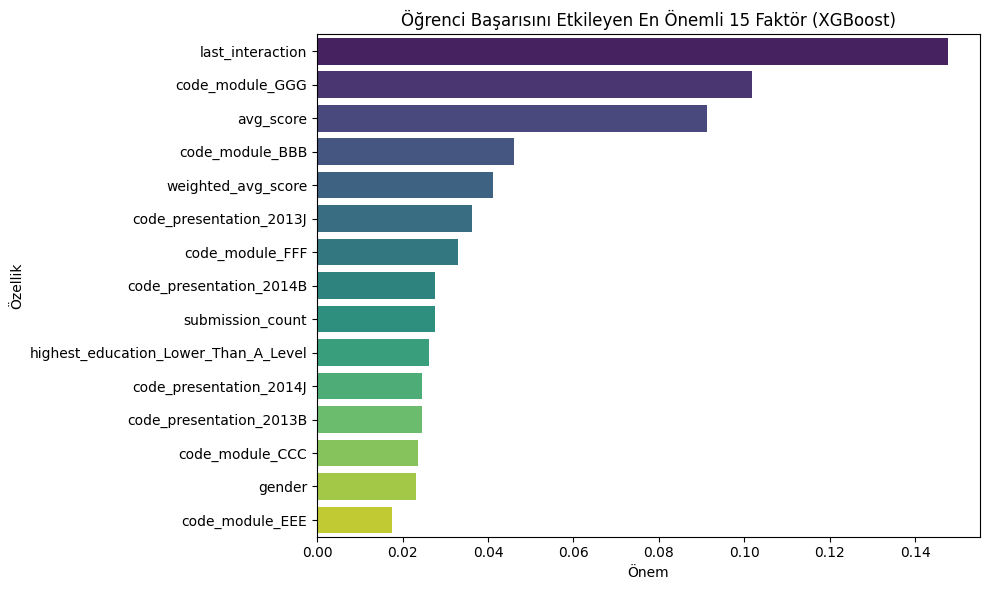

In [2]:
# XGBoost Feature Importance
importance = pd.DataFrame({
    'Özellik': X_test.columns,
    'Önem': xgb_model.feature_importances_
}).sort_values('Önem', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Önem', y='Özellik', palette='viridis')
plt.title('Öğrenci Başarısını Etkileyen En Önemli 15 Faktör (XGBoost)')
plt.tight_layout()
import os
os.makedirs('../visuals/report', exist_ok=True)
plt.savefig('../visuals/report/feature_importance.png')
plt.show()

## 3. Sonuç ve İş Çıkarımları
1. **Zaman Yönetimi:** Tahminlerde ilk sıralarda çıkması beklenen tıklama günleri (`active_days`) ve ödev gecikmeleri, öğrencilerin bağlılıklarını gösterir.
2. **Geçmiş Akademik Performans:** `avg_score` gibi önceki ödev notları başarının doğrudan göstergesidir.
3. **Erken Müdahale:** Modelin %76 bandındaki doğruluğu, okulu bırakma riski taşıyan öğrencilerin büyük kısmını önceden tespit edip akademik danışmanların proaktif müdahale etmesine olanak tanımaktadır.